In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [22]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!wget -nc $data

File ‘car_fuel_efficiency_2026.csv’ already there; not retrieving.



In [23]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [24]:
len(df)

10000

In [25]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [26]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [27]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


## Exploratory Data Analysis

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


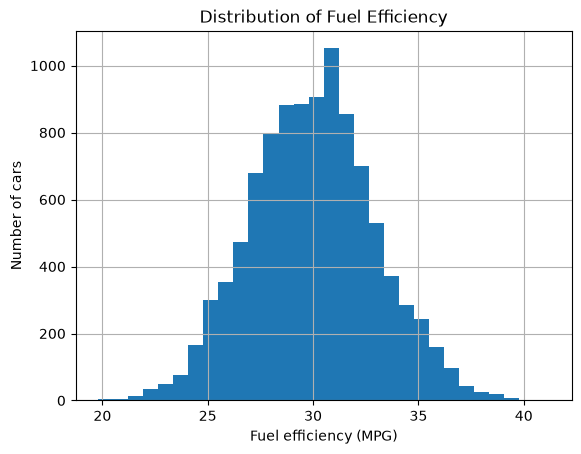

In [30]:
df["fuel_efficiency_mpg"].hist(bins=30)

plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Number of cars")
plt.title("Distribution of Fuel Efficiency")
plt.show()

In [31]:
df["fuel_efficiency_mpg"].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [32]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [34]:
df["horsepower"].median()

np.float64(254.0)

## Prepare and Split the Dataset

In [35]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [36]:
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
6252,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
4684,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
1731,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
4742,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4521,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7
...,...,...,...,...,...,...,...,...,...,...,...
7895,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5,29.8
9590,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1,25.1
7288,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2,27.7
278,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4,31.6


In [37]:
def prepare_X(df):
    df_num = df[
        [
            "engine_displacement",
            "horsepower",
            "vehicle_weight",
            "model_year"
        ]
    ]
    
    return df_num

In [38]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

## Linear Regression Function

In [39]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])
    
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    
    w = XTX_inv @ X.T @ y
    
    return w

## RMSE

In [40]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

Fill missing horsepower with 0

In [41]:
X_train = prepare_X(df_train).fillna(0).values
X_val = prepare_X(df_val).fillna(0).values

In [42]:
w = train_linear_regression(X_train, y_train)

In [43]:
X_val_with_ones = np.column_stack([np.ones(X_val.shape[0]), X_val])

y_pred = X_val_with_ones @ w

In [44]:
round(rmse(y_val, y_pred), 3)

np.float64(2.205)

Fill missing horsepower with the training mean

In [45]:
mean = df_train["horsepower"].mean()

In [46]:
X_train = prepare_X(df_train).fillna(mean).values
X_val = prepare_X(df_val).fillna(mean).values

In [47]:
w = train_linear_regression(X_train, y_train)

In [48]:
X_val_with_ones = np.column_stack([np.ones(X_val.shape[0]), X_val])

y_pred = X_val_with_ones @ w

In [49]:
round(rmse(y_val, y_pred), 3)

np.float64(2.202)

## Regularization

In [50]:
def train_linear_regression_reg(X, y, r):
    X = np.column_stack([np.ones(X.shape[0]), X])
    
    XTX = X.T @ X
    
    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0
    
    XTX_reg = XTX + reg
    
    XTX_inv = np.linalg.inv(XTX_reg)
    
    w = XTX_inv @ X.T @ y
    
    return w

In [51]:
X_train = prepare_X(df_train).fillna(0).values
X_val = prepare_X(df_val).fillna(0).values

In [52]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    w = train_linear_regression_reg(X_train, y_train, r)
    
    X_val_with_ones = np.column_stack([
        np.ones(X_val.shape[0]),
        X_val
    ])
    
    y_pred = X_val_with_ones @ w
    
    score = rmse(y_val, y_pred)
    
    print(r, round(score, 4))

0 2.2053
0.01 2.2053
0.1 2.2053
1 2.2053
5 2.2053
10 2.2053
100 2.2053


In [53]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    w = train_linear_regression_reg(X_train, y_train, r)
    
    X_val_with_ones = np.column_stack([
        np.ones(X_val.shape[0]),
        X_val
    ])
    
    y_pred = X_val_with_ones @ w
    
    score = rmse(y_val, y_pred)
    
    print(r, score)

0 2.2052931947534096
0.01 2.205293194801796
0.1 2.2052931952048342
1 2.205293199309741
5 2.2052932175509627
10 2.205293240380696
100 2.2052936541486763


## Random seed matter

In [54]:
scores = []

for seed in range(10):
    
    np.random.seed(seed)
    
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    X_train = prepare_X(df_train).fillna(0).values
    X_val = prepare_X(df_val).fillna(0).values
    
    y_train = df_train["fuel_efficiency_mpg"].values
    y_val = df_val["fuel_efficiency_mpg"].values
    
    w = train_linear_regression(X_train, y_train)
    
    X_val_with_ones = np.column_stack([
        np.ones(X_val.shape[0]),
        X_val
    ])
    
    y_pred = X_val_with_ones @ w
    
    score = rmse(y_val, y_pred)
    
    scores.append(score)
    
    print(seed, round(score, 3))

0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207


In [55]:
np.std(scores)

np.float64(0.02878127407819125)

In [56]:
round(np.std(scores), 3)

np.float64(0.029)

## Final test

In [57]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [58]:
df_full_train = pd.concat([df_train, df_val])

In [59]:
X_full_train = prepare_X(df_full_train).fillna(0).values
y_full_train = df_full_train["fuel_efficiency_mpg"].values

X_test = prepare_X(df_test).fillna(0).values
y_test = df_test["fuel_efficiency_mpg"].values

In [60]:
r = 0.001

In [61]:
w = train_linear_regression_reg(
    X_full_train,
    y_full_train,
    r
)

In [62]:
X_test_with_ones = np.column_stack([
    np.ones(X_test.shape[0]),
    X_test
])

y_pred = X_test_with_ones @ w

In [63]:
round(rmse(y_test, y_pred), 3)

np.float64(2.236)